In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import ipywidgets

In [3]:
bf = pd.read_csv('https://raw.githubusercontent.com/UIUC-iSchool-DataViz/is445_data/main/bfro_reports_fall2022.csv', parse_dates = ["date"])
bf

,observed,location_details,county,state,season,title,latitude,longitude,date,number,...,precip_intensity,precip_probability,precip_type,pressure,summary,uv_index,visibility,wind_bearing,wind_speed,location
0,Ed L. was salmon fishing with a companion in P...,East side of Prince William Sound,Valdez-Chitina-Whittier County,Alaska,Fall,NaN,NaN,NaN,NaT,1261.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,heh i kinda feel a little dumb that im reporti...,"the road is off us rt 80, i dont know the exit...",Warren County,New Jersey,Fall,NaN,NaN,NaN,NaT,438.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,I was on my way to Claremont from Lebanon on R...,Close to Claremont down 120 not far from Kings...,Sullivan County,New Hampshire,Summer,Report 55269: Dawn sighting at Stevens Brook o...,43.41549,-72.33093,2016-06-07,55269.0,...,0.001,0.7,rain,998.87,Mostly cloudy throughout the day.,6.0,9.70,262.0,0.49,POINT(-72.33093000000001 43.415490000000005)
3,I was northeast of Macy Nebraska along the Mis...,Latitude & Longitude : 42.158230 -96.344197,Thurston County,Nebraska,Spring,Report 59757: Possible daylight sighting of a ...,42.15685,-96.34203,2018-05-25,59757.0,...,0.000,0.0,NaN,1008.07,Partly cloudy in the morning.,10.0,8.25,193.0,3.33,POINT(-96.34203000000001 42.15685)
4,"While this incident occurred a long time ago, ...","Ward County, Just outside of a the Minuteman T...",Ward County,North Dakota,Spring,Report 751: Hunter describes described being s...,48.25422,-101.31660,2000-04-21,751.0,...,NaN,NaN,rain,1011.47,Partly cloudy until evening.,6.0,10.00,237.0,11.14,POINT(-101.3166 48.254220000000004)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4742,My cousin and I were camping way out in the wo...,"Indiana, Brown County, Elkinsville, Lake Monro...",Brown County,Indiana,Spring,NaN,NaN,NaN,NaT,2460.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4743,While backpacking near the horse trails and ac...,Near Bedford south of Brown County in the Hoos...,Brown County,Indiana,Winter,NaN,NaN,NaN,NaT,2461.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4744,My wife and I were camping At Yellowood State ...,Yellowood State Park. Off of highway 46 in bet...,Brown County,Indiana,Summer,Report 49480: Campers hear possible vocalizati...,39.17909,-86.33560,2015-08-08,49480.0,...,0.000,0.0,NaN,1014.02,Mostly cloudy in the evening.,9.0,9.22,256.0,0.34,POINT(-86.3356 39.17909)
4745,My wife and I were driving to Indianapolis to ...,On Interstate 65 in Indiana somewhere around t...,Boone County,Indiana,Winter,NaN,NaN,NaN,NaT,2459.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [204]:
bf.dtypes

observed                      object
location_details              object
county                        object
state                         object
season                        object
title                         object
latitude                     float64
longitude                    float64
date                  datetime64[ns]
number                       float64
classification                object
geohash                       object
temperature_high             float64
temperature_mid              float64
temperature_low              float64
dew_point                    float64
humidity                     float64
cloud_cover                  float64
moon_phase                   float64
precip_intensity             float64
precip_probability           float64
precip_type                   object
pressure                     float64
summary                       object
uv_index                     float64
visibility                   float64
wind_bearing                 float64
w

## Part 1:

<function matplotlib.pyplot.show(close=None, block=None)>

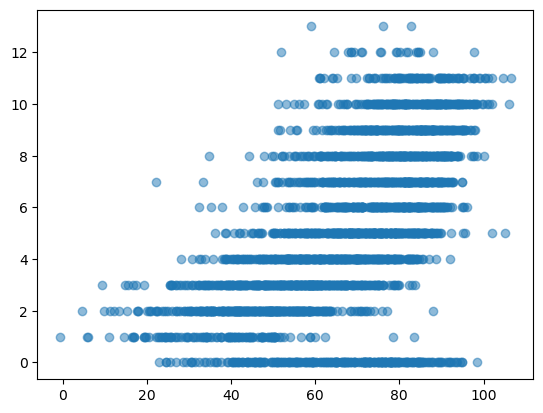

In [205]:
plt.scatter(bf['temperature_high'], bf['uv_index'], alpha=0.5)
plt.show

In [4]:
x_a = ['date', 'season', 'state', 'latitude', 'longitude', 'temperature_low', 'temperature_high', 'precip_intensity', 'cloud_cover', 'visibility']
y_a = ['date', 'season', 'state', 'latitude', 'longitude', 'temperature_low', 'temperature_high', 'precip_intensity', 'cloud_cover', 'visibility']
marker = [".", "o", "*"]
color = ipywidgets.ColorPicker()
cm = plt.colormaps()

@ipywidgets.interact(x_axis = x_a, y_axis = y_a, col = color, color_map = plt.colormaps(), mark = marker)
def bf_plot(x_axis, y_axis, mark, col, color_map):
    plt.scatter(bf[x_axis], bf[y_axis], marker = mark, c = col, cmap = color_map, alpha = 0.1)
    plt.colorbar()
    plt.xlabel(x_axis)
    plt.ylabel(y_axis)
    plt.title("plot")
    plt.show()

interactive(children=(Dropdown(description='x_axis', options=('date', 'season', 'state', 'latitude', 'longitud…

### Part 1 Write Up:

To construct the plot, I created a scatterplot where the user is allowed to customize a scatter plot in accordance to the given data. Only certain columns as those I felt were the most meaningful to the data. The users are alowed to alter the shape of the data points and choose whatever color they'd like. Additionally, I added labels to the axes that change in accordance to user preference. The color map argument was added to allow users to add various color palletes, but does not function. It should be noted that the data used for this plot and the second plot, has missing values included because I felt the values were important to include.

## Part 2:

In [262]:
column1 = ['date', 'season', 'state', 'latitude', 'longitude', 'temperature_low', 'temperature_high', 'precip_intensity', 'cloud_cover', 'visibility']
aggregate = ["min", "max", "mean", "median", "sum", "count"]
b = [5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20]

In [265]:
if isinstance(bf[column1], float):
    choice = input("Choose how to aggregate: min, mean, median, sum, count", )
    if choice == "min":
        min_bf  = bf.groupby(column1).agg("min").reset_index()          
        @ipywidgets.interact(x_ = column1, bins = b)
        def bf_hist1(x = column1, bins = [5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20]):
            plt.hist(min_bf[x], bins, edgecolor = "black")
            plt.show()
    elif choice == "mean":
        mean_bf  = bf.groupby(column1).agg("mean").reset_index()          
        @ipywidgets.interact(x = column1, bins = b)
        def bf_hist1(x = column1, bins =[5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20]):
            plt.hist(mean_bf[x], bins, edgecolor = "black")
            plt.show()
    elif choice == "median":
        med_bf  = bf.groupby(column1).agg("median").reset_index()          
        @ipywidgets.interact(x = column1, bins = b)
        def bf_hist1(x = column1, bins = [5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20]):
            plt.hist(med_bf[x], bins, edgecolor = "black")
            plt.show()
    elif choice == "sum":
        sum_bf  = bf.groupby(column1).agg("min").reset_index()          
        @ipywidgets.interact(x = column1, bins = b)
        def bf_hist1(x = column1, bins = [5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20]):
            plt.hist(sum_bf[x], bins, edgecolor = "black")
            plt.show()
    elif choice == "count":
        count_bf  = bf.groupby(column1).agg("count").reset_index()          
        @ipywidgets.interact(x = column1, bins = b)
        def bf_hist1(x = column1, bins = [5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20]):
            plt.hist(count_bf[x], bins, edgecolor = "black")
            plt.show()
    else:
        print("Error: Wrong Input!")
else: 
    choice = input("Choose how to aggregate: min, mean, median, sum, count", )
    if (choice == "min"):
        min_bf  = bf.groupby(column1).agg("min").reset_index()          
        @ipywidgets.interact(x = column1, bins = b)
        def bf_hist2(x = column1, bins = b):
            plt.hist(min_bf[x], bins, edgecolor = "black")
            plt.show()
    elif (choice == "mean"):
        mean_bf  = bf.groupby(column1).agg("mean").reset_index()          
        @ipywidgets.interact(x = column1, bins = b)
        def bf_hist2(x = column1, bins = b):
            plt.hist(mean_bf[x], bins, edgecolor = "black")
            plt.show()
    elif (choice == "median"):
        med_bf  = bf.groupby(column1).agg("median").reset_index()          
        @ipywidgets.interact(x = column1, bins = b)
        def bf_hist2(x = column1, bins = b):
            plt.hist(med_bf[x], bins, edgecolor = 'black')
            plt.show()
    elif (choice == "sum"):
        sum_bf  = bf.groupby(column1).agg("sum").reset_index()          
        @ipywidgets.interact(x = column1, bins = b)
        def bf_hist2(x = column1, bins = b):
            plt.hist(sum_bf[x], bins, edgecolor = "black")
            plt.show()
    elif (choice == "count"):
        count_bf  = bf.groupby(column1).agg("count").reset_index()          
        @ipywidgets.interact(x_axis = column1, bins = b)
        def bf_hist2(x = column1, bins = b):
            plt.hist(count_bf[x], bins, edgecolor = "black")
            plt.show()
    else:
        print("Error: Wrong Input!")

Choose how to aggregate: min, mean, median, sum, countmean


interactive(children=(Dropdown(description='x', options=('date', 'season', 'state', 'latitude', 'longitude', '…

#### Part 2 "prototype":

In [275]:
column_e = ['date', 'temperature_low', 'temperature_high', 'moon_phase', 'cloud_cover', 'visibility', 'precip_probability', 'humidity']
b = [5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20]

@ipywidgets.interact(x_axis = column_e, bins = b)
def bf_hist(x = column_e, bins = b):
    plt.hist(bf[x], bins)
    plt.show()

interactive(children=(Dropdown(description='x', options=('date', 'temperature_low', 'temperature_high', 'moon_…

### Part 2 Write Up:

With this plot, the user is allowed to aggregate thhe columns how they wish and then depnding on the data type of the chosen column, the histogram will show the coresponding number of bins chosen by the user. There is a limited number of options the user can select how their data is aggregated, via the input line, but the methods of aggregation are the most common methods typically used. An edge color was added to seperate the bins visually. The main issue I had with this plot is the binning. Initially, the binning widget didn't do anything for both column types, and after some tinkerig, a broblem regarding thecolumns was fixed but now binning works for all column types. An example of how the code should properly run (without aggregated data) was created as a model.

In [ ]:
[]